In [1]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# FORMAT — choose your acquisition system
FORMAT = 'mcs'   # 'spikeglx' | 'openephys' | 'mcs'

# SORTERS — one per format; each loader falls back to these if not overridden
SORTER_KS  = 'kilosort4'      # for spikeglx / openephys
SORTER_MCS = 'herdingspikes'  # for mcs

# PATHS — set the one matching FORMAT
spikeglx_folder  = Path(r'C:\Users\labuser\Ilaria\Project\small_rec\2142_g0\2142_g0_imec0')
openephys_folder = Path(r'C:\Users\labuser\Downloads\data for Ilaria\data for Ilaria\2023_09_13\2023-09-13_12-40-06_W3P12_first_piece_Pos2')
mcs_file         = Path(r'C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T11-17-48McsRecording_E-00218.h5')

if FORMAT == 'spikeglx':
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\processed\2142_output')
elif FORMAT == 'openephys':
    base_folder = Path(r'C:\Users\labuser\ilaria\Project\processed\openephys_output_2min')
elif FORMAT == 'mcs':
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min')

base_folder.mkdir(parents=True, exist_ok=True)

In [3]:
# COMMON PARAMETERS — shared across all formats
# Format-specific parameters (freq_min, sorter, cref_reference, etc.) are set in each loader.

job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

# Manual channel selection — list of channel IDs to keep; None → keep all.
manual_channel_ids = None

# Extra bad channels — force-remove on top of auto-detected ones.
extra_bad_channel_ids = []

# Artifact removal — timestamps (seconds) to blank; leave empty to skip.
artifact_timestamps_s = []
artifact_ms_before    = 2.0
artifact_ms_after     = 5.0

# WAVEFORM EXTRACTION
waveform_ms_before  = 1.5
waveform_ms_after   = 2.0
max_spikes_per_unit = 500

# QUALITY METRICS
metric_names = ['firing_rate', 'presence_ratio', 'snr', 'isi_violation', 'amplitude_cutoff']

# QUALITY FILTERING
amplitude_cutoff_thresh     = 0.1
isi_violations_ratio_thresh = 1
presence_ratio_thresh       = 0.9

MCSH5RecordingExtractor: 60 channels - 25000.000000 Hz - 1 segments - 4,860,000 samples 
                         194.40s (3.24 minutes) - int32 dtype - 1.09 GiB
  file_path: C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T11-17-48McsRecording_E-00218.h5
No probe geometry in file — using generic 6x10 grid (200 um pitch).


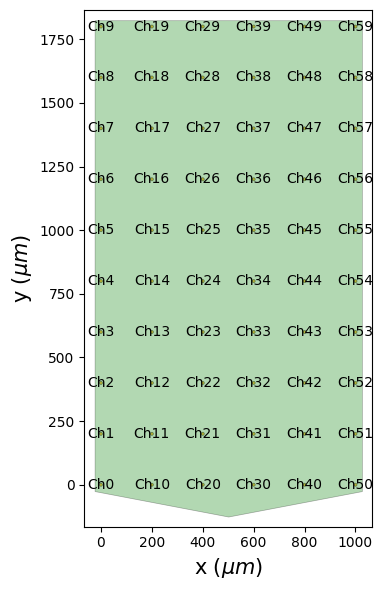

CommonReferenceRecording: 38 channels - 25000.000000 Hz - 1 segments - 4,860,000 samples 
                          194.40s (3.24 minutes) - int32 dtype - 704.50 MiB
Bad channels (22) saved -> C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\bad_channels.csv


C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\preprocessing\detect_bad_channels.py:300: UserWarning: Over 1/3 of channels are detected as bad. In the presence of a highnumber of dead / noisy channels, bad channel detection may fail (good channels may be erroneously labeled as dead).
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\preprocessing\common_reference.py:140: UserWarning: The following channels did not have enough neighbors in the annulus and used the closest 5 channels beyond the inner radius instead: Ch0, Ch1, Ch2, Ch3, Ch4, Ch5, Ch6, Ch7, Ch14, Ch22, Ch23, Ch24, Ch25, Ch26, Ch27, Ch28, Ch31, Ch32, Ch34, Ch35, Ch36, Ch37, Ch38, Ch40, Ch41, Ch42, Ch43, Ch44, Ch45, Ch47, Ch48, Ch49, Ch51, Ch53, Ch54, Ch55, Ch56, Ch57
  warnings.warn(


In [4]:
# DISPATCH — runs the format-specific loader, which sets up raw_rec, rec, and shared variables
if FORMAT == 'spikeglx':
    %run load_spikeglx.ipynb
elif FORMAT == 'openephys':
    %run load_openephys.ipynb
elif FORMAT == 'mcs':
    %run load_mcs.ipynb
else:
    raise ValueError(f"Unknown FORMAT '{FORMAT}'. Choose 'spikeglx', 'openephys', or 'mcs'.")

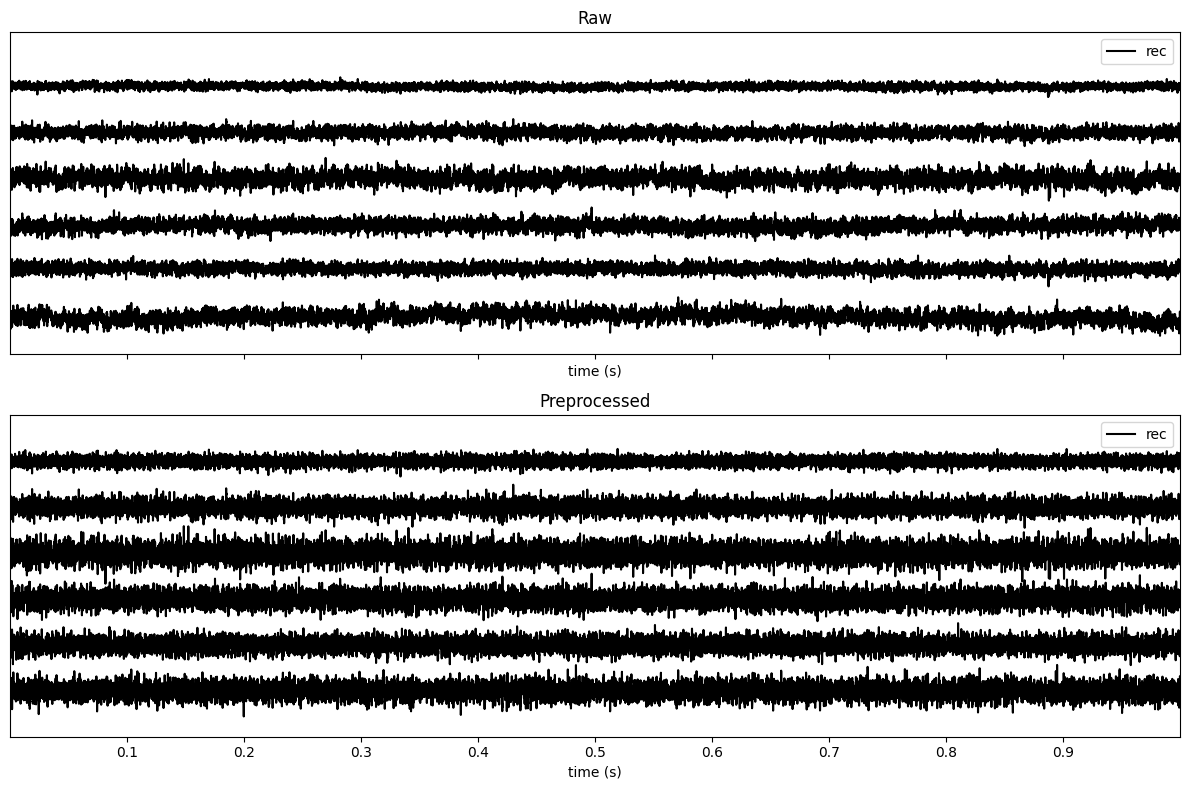

In [5]:
# TRACES VISUALIZATION
import re
_fs    = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

_nat_key     = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_good_ch_ids = [c for c in sorted(raw_rec.channel_ids, key=_nat_key) if c in set(rec.channel_ids)]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
si.plot_traces(raw_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[0])
si.plot_traces(rec_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[1])
axes[0].set_title('Raw')
axes[1].set_title('Preprocessed')
plt.tight_layout()
plt.show()

In [6]:
# SAVE PREPROCESSED RECORDING
import gc, shutil
try: del analyzer
except NameError: pass
try: del rec_analysis
except NameError: pass
try: del raw_rec
except NameError: pass
try: del rec1
except NameError: pass
try: del rec2
except NameError: pass
try: del rec3
except NameError: pass
gc.collect()

# On Windows, memory-mapped files from a previous kernel can stay locked.
# Try to reuse the existing preprocess folder; if corrupt/locked, save to a fresh one.
_pf = base_folder / 'preprocess'
_pf_loaded = False
if _pf.exists():
    try:
        rec = si.load(_pf)
        _pf_loaded = True
        print(f'Loaded existing preprocessed recording (delete {_pf} to force re-saving)')
    except Exception:
        _pf = base_folder / 'preprocess_new'
        shutil.rmtree(_pf, ignore_errors=True)
        print('Existing preprocess folder is locked/corrupt — saving to preprocess_new')
if not _pf_loaded:
    rec = rec.save(folder=_pf, format='binary',
                   overwrite=True, n_jobs=1, chunk_duration='1s', progress_bar=True)
    print(f'Preprocessed recording saved -> {_pf}')

# SPIKE SORTING
sorting = si.run_sorter(sorter, rec, folder=base_folder / f'{sorter}_output',
                        remove_existing_folder=True, verbose=True)
print(sorting)

Loaded existing preprocessed recording (delete C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\preprocess to force re-saving)
Chunk size not set, setting to 540540 samples.
HSDetection: Analysing segment 0, frames from        0 to   540540  (0.0%)
HSDetection: Analysing segment 0, frames from   540540 to  1081080  (11.1%)
HSDetection: Analysing segment 0, frames from  1081080 to  1621620  (22.2%)
HSDetection: Analysing segment 0, frames from  1621620 to  2162160  (33.4%)
HSDetection: Analysing segment 0, frames from  2162160 to  2702700  (44.5%)
HSDetection: Analysing segment 0, frames from  2702700 to  3243240  (55.6%)
HSDetection: Analysing segment 0, frames from  3243240 to  3783780  (66.7%)
HSDetection: Analysing segment 0, frames from  3783780 to  4324320  (77.9%)
HSDetection: Analysing segment 0, frames from  4324320 to  4860000  (89.0%)
writing spikes to C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\herdingspikes_output\sorte

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   3 out of  16 | elapsed:    8.9s remaining:   39.0s
[Parallel(n_jobs=16)]: Done  12 out of  16 | elapsed:    9.5s remaining:    3.1s


Number of estimated units: 32
Saving to C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\herdingspikes_output\sorter_output\HS2_sorted.hdf5
# Sampling rate: 24999.999999999996.
herdingspikes run time 17.50s
HerdingspikesSortingExtractor: 32 units - 1 segments - 25.0kHz
  file_path: C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\herdingspikes_output\sorter_output\HS2_sorted.hdf5


[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    9.8s finished


In [7]:
# SORTING ANALYZER
si.set_global_job_kwargs(n_jobs=1, chunk_duration='1s', progress_bar=True)

rec_analysis = si.load(_pf)

analyzer = si.create_sorting_analyzer(sorting, rec_analysis, sparse=_analyzer_sparse, format='memory')

analyzer.compute('random_spikes', method='uniform', max_spikes_per_unit=max_spikes_per_unit)
analyzer.compute('waveforms', ms_before=waveform_ms_before, ms_after=waveform_ms_after)
analyzer.compute('templates', operators=['average', 'median', 'std'])
analyzer.compute('noise_levels')
analyzer.compute('correlograms')
analyzer.compute('unit_locations')
analyzer.compute('spike_amplitudes')
analyzer.compute('template_similarity')
print(analyzer)

compute_waveforms (no parallelization):   0%|          | 0/195 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/195 [00:00<?, ?it/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


SortingAnalyzer: 37 channels - 32 units - 1 segments - memory - has recording
Loaded 8 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity


In [8]:
# QUALITY METRICS
metrics_ext = analyzer.compute('quality_metrics', metric_names=metric_names)
metrics     = metrics_ext.get_data()
print(metrics)
metrics.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved -> {base_folder / 'quality_metrics.csv'}")

    firing_rate  presence_ratio        snr  isi_violations_ratio  \
0     10.411523             1.0  11.472895              3.353435   
1     12.592593             1.0  13.350726              2.519464   
2      7.926955             1.0  10.618401              1.828288   
3      9.444444             1.0  12.661251              2.633602   
4      4.531893             1.0  11.787779              0.834878   
5      2.818930             1.0   7.393689              4.747190   
6      3.729424             1.0   9.228439              3.821736   
7      3.559671             1.0  10.177539              6.766013   
8      2.042181             1.0   8.906890              2.878008   
9      1.939300             1.0   7.391034              1.367772   
10     1.913580             1.0   7.861877              5.150884   
11     1.625514             1.0   8.338292              1.946803   
12     1.419753             1.0   6.793043              0.850662   
13     1.157407             1.0   8.624287      

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning: Amplitude cutoff set to NaN for units [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]: too few spikes (< 500).
  warnings.warn(


In [9]:
# QUALITY-BASED FILTERING
_conditions = []
if not metrics['amplitude_cutoff'].isna().all():
    _conditions.append(f"(amplitude_cutoff < {amplitude_cutoff_thresh})")
_conditions.append(f"(isi_violations_ratio < {isi_violations_ratio_thresh})")
if not metrics['presence_ratio'].isna().all():
    _conditions.append(f"(presence_ratio > {presence_ratio_thresh})")
query = " & ".join(_conditions)

keep_unit_ids = metrics.query(query).index.values
print(f"Keeping {len(keep_unit_ids)} / {len(sorting.unit_ids)} units after quality filtering")
if metrics['amplitude_cutoff'].isna().all():
    print("Note: amplitude_cutoff skipped (all NaN — too few spikes per unit)")
if metrics['presence_ratio'].isna().all():
    print("Note: presence_ratio skipped (all NaN — recording shorter than 60s bin)")

analyzer = analyzer.select_units(keep_unit_ids)

Keeping 1 / 32 units after quality filtering


In [10]:
# EXPORT FINAL SPIKE TIMES
_spike_times_folder = base_folder / 'spike_times'
_spike_times_folder.mkdir(exist_ok=True)

_fs_export = rec_analysis.get_sampling_frequency()
for uid in keep_unit_ids:
    _train   = sorting.get_unit_spike_train(uid, segment_index=0)
    _times_s = _train / _fs_export
    np.savetxt(
        _spike_times_folder / f'unit_{uid}.csv',
        _times_s,
        delimiter=',', header='time_s', comments='', fmt='%.6f'
    )
print(f'Spike times for {len(keep_unit_ids)} units -> {_spike_times_folder}')

Spike times for 1 units -> C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\spike_times


In [11]:
# PIPELINE LOG
import json as _json, datetime as _dt

_log = {
    'timestamp':       _dt.datetime.now().isoformat(),
    'si_version':      si.__version__,
    'format':          FORMAT,
    'source_path':     _source_path,
    'sorter':          sorter,
    'n_channels_raw':  int(_n_raw_channels),
    'n_channels_kept': int(rec_analysis.get_num_channels()),
    'bad_channel_ids': [str(c) for c in bad_channel_ids],
    'n_units_sorted':  int(len(sorting.unit_ids)),
    'n_units_kept':    int(len(keep_unit_ids)),
    'parameters': {
        'freq_min':                    freq_min,
        'cref_operator':               cref_operator,
        'cref_reference':              cref_reference,
        'waveform_ms_before':          waveform_ms_before,
        'waveform_ms_after':           waveform_ms_after,
        'max_spikes_per_unit':         max_spikes_per_unit,
        'amplitude_cutoff_thresh':     amplitude_cutoff_thresh,
        'isi_violations_ratio_thresh': isi_violations_ratio_thresh,
        'presence_ratio_thresh':       presence_ratio_thresh,
    },
}
_log_path = base_folder / 'pipeline_run_log.json'
_log_path.write_text(_json.dumps(_log, indent=2))
print(f'Run log -> {_log_path}')

Run log -> C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min\pipeline_run_log.json


In [12]:
# SAVE ANALYZER
import shutil
_analyzer_folder = base_folder / 'analyzer'
if _analyzer_folder.exists():
    shutil.rmtree(_analyzer_folder)
analyzer.save_as(folder=_analyzer_folder, format='binary_folder')

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\core\basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


SortingAnalyzer: 37 channels - 1 units - 1 segments - binary_folder - has recording
Loaded 9 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, quality_metrics

In [13]:
# INTERACTIVE VIEWER (sigui)
# shows waveforms, ISI, amplitudes, probe map — click any unit to inspect
import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)